In [230]:
import pandas as pd
import sys
import itertools
import tqdm
import numpy as np

In [231]:
sys.path.insert(0, '')
from Clase_Valor import Valor
from Transversal import leer_activos, leer_parametros, leer_configuracion

In [232]:
solo_rendimientos_positivos = False

In [233]:
carpeta_input, cofre, seguimiento, saving_step = leer_parametros()
output_level = leer_configuracion()

In [234]:
df_activos = leer_activos(carpeta_input)

Small batch 240812


In [235]:
# Small batch
#df_activos = df_activos[df_activos['SIMBOLO'].isin(['NFLX', 'AAPL', 'CAT'])].reset_index(drop = True) # small batch
print('small batch')
df_activos = df_activos.head(6)
df_activos

small batch


,SIMBOLO,NOMBRE
0,NFLX,"Netflix, Inc."
1,FCEL,"FuelCell Energy, Inc."
2,DVA,DaVita Inc.
3,AAPL,AAPL
4,CAT,CAT


In [236]:
# Algoritmo

def algoritmo_mkw(df_W_iter, df_covarianza, R_TOTAL):
    
    #print('LEN2', len(df_W_iter))
    df_W_iter['w'] = 1 / len(df_W_iter)
    #df_W_iter = df_W_iter.merge(df_var, how = 'left', on = 'VALOR')
    
    #display('df_W_iter')
    #display(df_W_iter)

    while True:
        
        #display('df_W_iter iteracion0')
        #display(df_W_iter)
        df_W_iter['A'] = df_W_iter['r'] / df_W_iter['VAR']
        df_W_iter['B'] = 1 / df_W_iter['VAR']

        df_C = pd.DataFrame()
        for value_1 in df_W_iter['VALOR'].unique():
            df_covarianza_i = df_covarianza[(df_covarianza['VALOR_1'] == value_1) & (df_covarianza['VALOR_2'] != value_1)].reset_index(drop = True)
            df_covarianza_i = df_covarianza_i.merge(df_W_iter[['VALOR', 'w']], how = 'left', left_on = 'VALOR_2', right_on = 'VALOR')
            df_covarianza_i['COV_W'] = df_covarianza_i['COV'] * df_covarianza_i['w']
            num_value = df_covarianza_i['COV_W'].sum()
            df_c_new = pd.DataFrame({'VALOR': [value_1], 'C': [num_value]})
            df_C = pd.concat([df_C, df_c_new]).reset_index(drop = True)

        #display('df_W_iter iteracion1')
        ##display(df_W_iter)
        df_W_iter = df_W_iter.merge(df_C, how = 'left', on = 'VALOR')
        df_W_iter['C'] = df_W_iter['C'] / df_W_iter['VAR']

        # mu1 y mu2
        df_W_iter['D'] = df_W_iter['B'] * df_W_iter['r']
        D = df_W_iter['D'].sum()

        df_W_iter['E'] = df_W_iter['C'] * df_W_iter['r']
        E = df_W_iter['E'].sum() + R_TOTAL

        df_W_iter['F'] = df_W_iter['A'] * df_W_iter['r']
        F = df_W_iter['F'].sum()

        G = df_W_iter['C'].sum() + 1

        H = df_W_iter['A'].sum()

        I = df_W_iter['B'].sum()

        mu2 = ((G / I) - ((E * H) / (F * I))) / (1 - ((D * H) / (F * I)))
        
        mu2_aux = (F*G-E*H)/(I*F-D*H)
        
        den = (1 - (D * H) / (F * I)) * (10**10)
        num = (G / I) - ((E * H) / (F * I)) * (10**10)
        #print('MU2', mu2, mu2_aux, num, den)
        mu1 = (E - mu2 * D) / F

        #print('mus', mu1, mu2)
        
        #print(D, E, F, G, H, I)
        

        # w_new = A * mu1 + B * mu2 - C
        df_W_iter['w_new'] = df_W_iter['A'] * mu1 + df_W_iter['B'] * mu2 - df_W_iter['C']
        if len(df_W_iter) == 1:
            df_W_iter['w_new'] = 1
        elif (abs(mu1) > 10 ** 15) or (abs(mu2) > 10 ** 15):
            sys.exit('Salida por divergencia, revisar fórmula de cálculo de mus y replantear si es necesario')
        
        df_W_iter['delta'] = abs(df_W_iter['w_new'] - df_W_iter['w'])
        
        #display('df_W_iter iteracion2')
        #display(df_W_iter)

        delta = df_W_iter['delta'].sum()

        #print(delta)
        if delta < 0.001:
            break

        df_W_iter = df_W_iter[['VALOR', 'r', 'w_new', 'VAR']].rename(columns = {'w_new': 'w'})
        
        #display('df_W_iter iteracion')
        #display(df_W_iter)

    if df_W_iter['w'].min() < 0:
        return df_W_iter, pd.DataFrame(), 0, False # Cambiar combinación
    
    df_W_iter['rend_total'] = df_W_iter['r'] * df_W_iter['w']
    rend_total = df_W_iter['rend_total'].sum()

    # cov total
    df_covarianza_total = df_covarianza.copy()
    df_W1 = df_W_iter[['VALOR', 'w']].rename(columns = {'VALOR': 'VALOR_1', 'w': 'w1'})
    df_covarianza_total = df_covarianza_total.merge(df_W1, how = 'left', on = 'VALOR_1')
    df_W2 = df_W_iter[['VALOR', 'w']].rename(columns = {'VALOR': 'VALOR_2', 'w': 'w2'})
    df_covarianza_total = df_covarianza_total.merge(df_W2, how = 'left', on = 'VALOR_2')
    df_covarianza_total['cov_total'] = df_covarianza_total['COV'] * df_covarianza_total['w1'] * df_covarianza_total['w2']
    cov_total = df_covarianza_total['cov_total'].sum()
    #cov_total

    df_resultados_new = pd.DataFrame({'REND_TOTAL': [rend_total], 'COV_TOTAL': [cov_total]})
    
    #sys.exit('Salida OK')
    return df_W_iter, df_resultados_new, cov_total, True



In [237]:
lista_activos = list(df_activos['SIMBOLO'].unique())

In [238]:
df_rendimiento = pd.read_csv(f'{cofre}Inputs_mkw/Rendimiento_{output_level}.csv', sep = ';', decimal = ',')
df_rendimiento = df_rendimiento[['VALOR', 'y']]
df_rendimiento = df_rendimiento[df_rendimiento['VALOR'].isin(lista_activos)].reset_index(drop = True)

print('Eliminar esto!!!!!!!!!!! (1)')
print('Eliminar esto!!!!!!!!!!! (1)')
print('Eliminar esto!!!!!!!!!!! (1)')
#df_rendimiento['y'] = abs(df_rendimiento['y'])
display(df_rendimiento.head())

df_covarianza = pd.read_csv(f'{cofre}Inputs_mkw/Covarianza_{output_level}.csv', sep = ';', decimal = ',')
df_covarianza = df_covarianza[df_covarianza['VALOR_1'].isin(lista_activos) & df_covarianza['VALOR_2'].isin(lista_activos)].reset_index(drop = True)
display(df_covarianza.head())


df_var = df_covarianza[df_covarianza['VALOR_1'] == df_covarianza['VALOR_2']].reset_index(drop = True)
df_var = df_var[['VALOR_1', 'COV']].rename(columns = {'VALOR_1': 'VALOR', 'COV': 'VAR'})

Eliminar esto!!!!!!!!!!! (1)
Eliminar esto!!!!!!!!!!! (1)
Eliminar esto!!!!!!!!!!! (1)


,VALOR,y
0,AAPL,0.000830
1,CAT,-0.000281
2,DVA,-0.000051
3,FCEL,0.006320
4,NFLX,0.000578


,VALOR_1,VALOR_2,COV
0,AAPL,AAPL,0.000144
1,AAPL,DVA,0.000011
2,AAPL,FCEL,0.000062
3,AAPL,NFLX,0.000047
4,CAT,AAPL,0.000027


In [239]:
if solo_rendimientos_positivos:
    df_rendimiento = df_rendimiento[df_rendimiento['y'] > 0].reset_index(drop = True)
df_rendimiento

,VALOR,y
0,AAPL,0.000830
1,CAT,-0.000281
2,DVA,-0.000051
3,FCEL,0.006320
4,NFLX,0.000578


In [240]:
df_resultados, df_W_total = pd.DataFrame(), pd.DataFrame()

R_TOTAL = df_rendimiento['y'].min()

n_particiones = 10

for n_rend in tqdm.tqdm(range(n_particiones + 1)):
#while R_TOTAL <= df_rendimiento['VALOR'].max():
    
    print('R_TOTAL', R_TOTAL)
    df_W = df_rendimiento[['VALOR', 'y']].rename(columns = {'VALOR': 'VALOR', 'y': 'r'})
    df_W = df_W.merge(df_var, how = 'left', on = 'VALOR')
    df_W = df_W.sort_values(by = 'r').reset_index(drop = True)
    display(df_W)
    #sys.exit()
    # Inicialización (1)
    
    k = len(lista_activos)
    if n_rend in [0, n_particiones]: # el minimo o el maximo
        k = 1
        
    salir = False
    while not salir:
        
        best_cov = float('inf')
        best_df_W, best_df_resultados_new = pd.DataFrame(), pd.DataFrame() # Por defecto, en caso de no encontrar un resultado
        combinaciones = list(itertools.combinations(lista_activos, k))
        
        for combinacion in combinaciones: # Combinaciones para qu todo w sea >= 0
            #print(combinacion)
            combinacion = list(combinacion)
            if n_rend == 0:
                combinacion = [df_W['VALOR'][0]]
            elif n_rend == n_particiones:
                combinacion = [df_W['VALOR'][len(df_W) - 1]]
            #print(combinacion, len(combinacion))
            df_W_iter = df_W[df_W['VALOR'].isin(combinacion)]
            
            #print('df_W_iter', len(df_W_iter))
            #display(df_W_iter)
            
            df_W_iter, df_resultados_new, cov, aprobado = algoritmo_mkw(df_W_iter, df_covarianza, R_TOTAL)
            
            #sys.exit()
            if aprobado:
                salir = True
                #print('df_W_iter 0')
                #display(df_W_iter)
                if cov < best_cov:
                    best_df_W = df_W_iter.copy()
                    best_df_resultados_new = df_resultados_new.copy()
                    best_cov = cov
        
        k -= 1
        
        if salir or (k == 0):
            break
    
    best_df_resultados_new['ID'] = n_rend
    df_resultados = pd.concat([df_resultados, best_df_resultados_new]).reset_index(drop = True)
    best_df_W['R_TOTAL'] = R_TOTAL
    best_df_W['ID'] = n_rend
    
    display('best_df_W óptimo')
    display(best_df_W)
            
    df_W_total = pd.concat([df_W_total, best_df_W]).reset_index(drop = True)
    
    R_TOTAL += (df_rendimiento['y'].max() - df_rendimiento['y'].min()) / n_particiones
    

df_resultados

  0%|          | 0/11 [00:00<?, ?it/s]

R_TOTAL -0.00028084219


,VALOR,r,VAR
0,CAT,-0.000281,0.000152
1,DVA,-0.000051,0.000137
2,NFLX,0.000578,0.000109
3,AAPL,0.000830,0.000144
4,FCEL,0.006320,0.002376


'best_df_W óptimo'

,VALOR,r,VAR,w,A,B,C,D,E,F,w_new,delta,rend_total,R_TOTAL,ID
0,CAT,-0.000281,0.000152,1.0,-1.848518,6582.051303,0.0,-1.848518,-0.0,0.000519,1,0.0,-0.000281,-0.000281,0


...

,VALOR,r,VAR
0,CAT,-0.000281,0.000152
1,DVA,-0.000051,0.000137
2,NFLX,0.000578,0.000109
3,AAPL,0.000830,0.000144
4,FCEL,0.006320,0.002376


'best_df_W óptimo'

,VALOR,r,VAR,w,A,B,C,D,E,F,w_new,delta,rend_total,R_TOTAL,ID
0,FCEL,0.00632,0.002376,1.0,2.65957,420.818052,0.0,2.65957,0.0,0.016808,1,0.0,0.00632,0.00632,10


100%|██████████| 11/11 [00:06<00:00,  1.73it/s]


,REND_TOTAL,COV_TOTAL,ID
0,-0.000281,0.000152,0
1,0.000379,0.000045,1
2,0.001039,0.000071,2
3,0.001699,0.000133,3
4,0.002359,0.000253,4
5,0.003020,0.000439,5
6,0.003680,0.000691,6
7,0.004340,0.001008,7
8,0.005000,0.001391,8
9,0.005660,0.001848,9


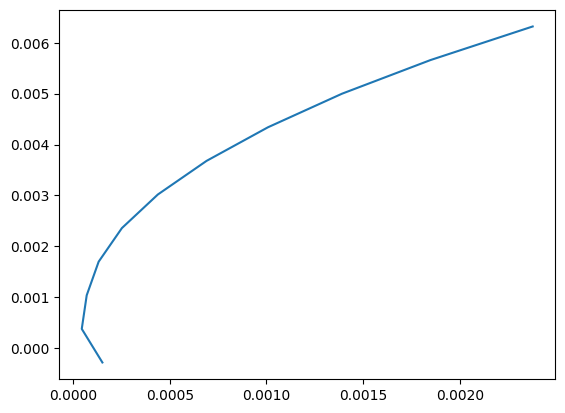

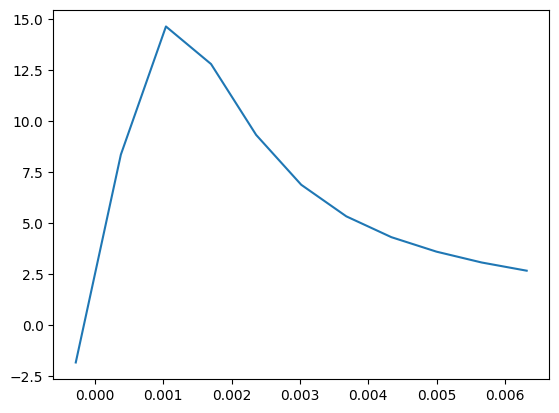

In [241]:
# grafica RND_TOTAL en el eje X y COV_TOTAL en el eje y
import matplotlib.pyplot as plt
plt.plot(df_resultados['COV_TOTAL'], df_resultados['REND_TOTAL'])
plt.show()
plt.plot(df_resultados['REND_TOTAL'], df_resultados['REND_TOTAL'] / df_resultados['COV_TOTAL'])
plt.show()

In [242]:
df_resultados

,REND_TOTAL,COV_TOTAL,ID
0,-0.000281,0.000152,0
1,0.000379,0.000045,1
2,0.001039,0.000071,2
3,0.001699,0.000133,3
4,0.002359,0.000253,4
5,0.003020,0.000439,5
6,0.003680,0.000691,6
7,0.004340,0.001008,7
8,0.005000,0.001391,8
9,0.005660,0.001848,9


In [243]:
import datetime as dt
import os
name_now = dt.datetime.now().strftime('%Y%m%d_%H%M%S')
#name = dt.datetime.now().strftime('%Y%m%d')
#if name_now not in os.listdir(f'{cofre}Resultados_mkw'):
#    os.mkdir(f'{cofre}Resultados_mkw/{name}')

df_W_total['VERSION'] = name_now
df_W_total = df_W_total[['VERSION', 'ID', 'R_TOTAL', 'VALOR', 'w']]
df_resultados['VERSION'] = name_now
df_resultados = df_resultados[['VERSION', 'ID', 'REND_TOTAL', 'COV_TOTAL']]


In [244]:
carpeta_resultados = f'{cofre}Resultados_mkw/'

In [245]:
df_W_total_all = pd.DataFrame() 
if 'df_W_total.csv' in os.listdir(carpeta_resultados):
    df_W_total_all = pd.read_csv(f'{carpeta_resultados}df_W_total.csv', sep = ';', decimal = ',')
df_W_total_all = pd.concat([df_W_total_all, df_W_total]).reset_index(drop = True)
df_W_total_all.to_csv(f'{carpeta_resultados}df_W_total.csv', sep = ';', decimal = ',', index = False) # Representa, en cada ejecución (versión) y en cada etrategia (ID), los pesos que deberían estar en cartera 

df_resultados_all = pd.DataFrame()
if 'df_resultados.csv' in os.listdir(carpeta_resultados):
    df_resultados_all = pd.read_csv(f'{carpeta_resultados}df_resultados.csv', sep = ';', decimal = ',')
df_resultados_all = pd.concat([df_resultados_all, df_resultados]).reset_index(drop = True)
df_resultados_all.to_csv(f'{carpeta_resultados}df_resultados.csv', sep = ';', decimal = ',', index = False)

# Ejecutar estrategia

In [246]:
df_precio = pd.DataFrame()
cofre0 = '/'.join(cofre.split('/')[:-2]) + '/'
for i in range(len(df_activos)):
    simbolo, nombre = df_activos.loc[i]
    print(simbolo)
    valor = Valor(simbolo, nombre, cofre) # Si no existe el objeto, se crea 
    valor.extraer_data()
    valor.ajustar_data()
    
    df_precio_valor = valor.raw_data # Se consideran los precios reales de los activos
    df_base_dates = pd.DataFrame({'Date': pd.date_range(start = df_precio_valor['Date'].min(), end = df_precio_valor['Date'].max())}) # Se crea un dataframe con todas las fechas
    
    print('Ejemplo funcional "date" con pandas nuevo')
    #date_0 = pd.to_datetime(date_0) # Convertir 'date_0' a datetime64[ns]
    df_precio_valor['Date'] = pd.to_datetime(df_precio_valor['Date']) # Convertir 'Date' en 'self.adj_data' a datetime64[ns]
    
    #self.raw_data['Date'] = pd.to_datetime(self.raw_data['Date']).dt.date
    #df_base_dates['Date'] = pd.to_datetime(df_base_dates['Date']).dt.date  # Asegúrate de que también 'df_base_dates' tenga 'Date' como datetime
    df_precio_valor = df_base_dates.merge(df_precio_valor, on = 'Date', how = 'left') # Merge con la data existente

    df_precio_valor[['Open', 'High', 'Low', 'Close', 'Volume']] = df_precio_valor[['Open', 'High', 'Low', 'Close', 'Volume']].interpolate(method = 'linear').astype(float) # Interpolacion y declaración de precios y volumenes como floats
    
    df_precio_valor = df_precio_valor[['Date', 'Close']].rename(columns = {'Date': 'DATE', 'Close': 'PRECIO'})
    df_precio_valor['VALOR'] = simbolo
    df_precio_valor = df_precio_valor[['VALOR', 'DATE', 'PRECIO']]
    df_precio = pd.concat([df_precio, df_precio_valor]).reset_index(drop = True)

date = dt.datetime.now().date()
if df_precio['DATE'].max().date() + dt.timedelta(days = 1) != date:
    sys.exit('Error con los días..día máximo en precios, no es ayer')
            
df_precio

NFLX
NFLX.pkl ../Cofre/Valor/
../Cofre/Valor/NFLX.pkl
[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


,Date,Open,High,Low,Close,Adj Close,Volume
5601,2024-08-23,694.130005,696.070007,678.630005,686.729980,686.729980,2354500
5602,2024-08-26,687.260010,690.590027,681.640015,688.440002,688.440002,1354200
5603,2024-08-27,688.530029,707.890015,686.919983,695.719971,695.719971,3164900
5604,2024-08-28,695.830017,696.669983,677.099976,683.840027,683.840027,2430600
5605,2024-08-29,690.000000,699.799988,686.070007,692.479980,692.479980,2185300


Ejemplo funcional "date" con pandas nuevo
Ejemplo funcional "date" con pandas nuevo
FCEL
FCEL.pkl ../Cofre/Valor/
../Cofre/Valor/FCEL.pkl
[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,1992-06-25,219.0,222.0,216.0,219.0,213.136520,7783
1,1992-06-26,219.0,219.0,216.0,216.0,210.216843,5529
2,1992-06-29,216.0,219.0,216.0,219.0,213.136520,1292
3,1992-06-30,219.0,219.0,216.0,216.0,210.216843,2154
4,1992-07-01,216.0,219.0,216.0,219.0,213.136520,1475


...

Ejemplo funcional "date" con pandas nuevo
Ejemplo funcional "date" con pandas nuevo
CAT
CAT.pkl ../Cofre/Valor/
../Cofre/Valor/CAT.pkl
[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,1.604167,0.473001,163200
1,1962-01-03,1.604167,1.619792,1.588542,1.619792,0.477609,156000
2,1962-01-04,1.656250,1.708333,1.656250,1.661458,0.489894,355200
3,1962-01-05,1.661458,1.697917,1.656250,1.677083,0.494501,163200
4,1962-01-08,1.677083,1.703125,1.666667,1.687500,0.497573,204000


,Date,Open,High,Low,Close,Adj Close,Volume
15768,2024-08-23,344.970001,349.540009,343.070007,348.410004,348.410004,2183900
15769,2024-08-26,349.809998,354.410004,348.940002,351.160004,351.160004,1718100
15770,2024-08-27,350.350006,351.720001,347.100006,351.119995,351.119995,1210800
15771,2024-08-28,350.589996,354.429993,345.839996,348.200012,348.200012,1514500
15772,2024-08-29,351.220001,356.459991,347.489990,351.640015,351.640015,1664500


Ejemplo funcional "date" con pandas nuevo
Ejemplo funcional "date" con pandas nuevo


,VALOR,DATE,PRECIO
0,NFLX,2002-05-23,1.196429
1,NFLX,2002-05-24,1.210000
2,NFLX,2002-05-25,1.196786
3,NFLX,2002-05-26,1.183572
4,NFLX,2002-05-27,1.170357
...,...,...,...
69268,CAT,2024-08-25,350.243337
69269,CAT,2024-08-26,351.160004
69270,CAT,2024-08-27,351.119995
69271,CAT,2024-08-28,348.200012


Si no existe la estrategia, crear (comprando 100, distribuido eficientemente)
Si existe...revisar cada uno de los días desde el último movimiento, cuanto vale realmente la cartera (día a día tiene que quedar un registro, en cada estrategia)
"Vender" todos los activos el día actual, y con esa misma plata, comprar los activos con la nueva distribución

Outputs:

1. BD que contiene los campos: ID ESTRATEGIA | DÍA | VALOR (ACTIVO) | COMPRA O VENTA | PRECIO DE COMPRA O VENTA | MONTO ($)
2. BD que contiene los campos: ID ESTRATEGIA | DÍA | MONTO CARTERA ($)

In [247]:

def registrar_compra(df_precio, id_level, version_id, df_W_total_id_level, monto_actual): # comprar
    df_precio_ejecucion = df_precio[df_precio['DATE'] == df_precio['DATE'].max()].reset_index(drop = True) # Se asume que la transacción es al precio de cierre del día de ayer

    df_precio_ejecucion['TIPO_TRANSACCION'] = 'COMPRA'
    df_precio_ejecucion['ID_ESTRATEGIA'] = id_level
    df_precio_ejecucion['VERSION_ID'] = version_id
    df_precio_ejecucion = df_precio_ejecucion[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO']]
    df_W_total_id_level = df_W_total_id_level[['VALOR', 'w']].rename(columns = {'w':  'W'})
    df_W_total_id_level['MONTO'] = monto_actual * df_W_total_id_level['W']
    df_W_total_id_level = df_W_total_id_level[['VALOR', 'MONTO']]
    df_precio_ejecucion = df_precio_ejecucion.merge(df_W_total_id_level, how = 'left', on = 'VALOR')
    df_precio_ejecucion = df_precio_ejecucion[df_precio_ejecucion['MONTO'].notna()].reset_index(drop = True)
    df_precio_ejecucion['UNIDADES'] = df_precio_ejecucion['MONTO'] / df_precio_ejecucion['PRECIO']
    df_precio_ejecucion['DATE'] = pd.to_datetime(df_precio_ejecucion['DATE'])
    return df_precio_ejecucion

In [248]:
def registrar_venta(df_detalle_all, id_level, version_id):
    df_detalle_all_para_vender = df_detalle_all[df_detalle_all['TIPO_TRANSACCION'] == 'COMPRA'] # se filtran las últimas compras
    df_detalle_all_para_vender = df_detalle_all_para_vender[df_detalle_all_para_vender['DATE'] == df_detalle_all_para_vender['DATE'].max()].reset_index(drop = True) # se filtran las últimas compras
    df_detalle_all_para_vender = df_detalle_all_para_vender[df_detalle_all_para_vender['ID_ESTRATEGIA'] == id_level].reset_index(drop = True) # se filtran el id de la estrategia en particular

    df_detalle_all_para_vender = df_detalle_all_para_vender[['VERSION_ID', 'ID_ESTRATEGIA', 'VALOR', 'UNIDADES']] # haberes actuales
    # Venta
    df_precio_ejecucion = df_precio[df_precio['DATE'] == df_precio['DATE'].max()].reset_index(drop = True) # Se asume que la transacción es al precio de cierre del día de ayer
    df_precio_ejecucion['TIPO_TRANSACCION'] = 'VENTA'
    df_precio_ejecucion['ID_ESTRATEGIA'] = id_level
    df_precio_ejecucion['VERSION_ID'] = version_id
    df_precio_ejecucion = df_precio_ejecucion[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO']]
    df_precio_ejecucion = df_detalle_all_para_vender.merge(df_precio_ejecucion, how = 'left', on = ['VALOR', 'VERSION_ID', 'ID_ESTRATEGIA']) # precio asociado a los activos
    df_precio_ejecucion['MONTO'] = df_precio_ejecucion['UNIDADES'] * df_precio_ejecucion['PRECIO'] # monto
    monto_actual = df_precio_ejecucion['MONTO'].sum()
    df_precio_ejecucion = df_precio_ejecucion[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO', 'MONTO', 'UNIDADES']] # selección de columnas
    df_precio_ejecucion['DATE'] = pd.to_datetime(df_precio_ejecucion['DATE'])
    return df_precio_ejecucion, monto_actual

In [249]:
def generar_transacciones(df_precio_ejecucion_compra, df_precio_ejecucion_venta):
    df_precio_ejecucion_compra_resumen = df_precio_ejecucion_compra[['VALOR', 'MONTO', 'UNIDADES']].rename(columns = {'MONTO': 'MONTO_COMPRA', 'UNIDADES': 'UNIDADES_COMPRA'})
    df_precio_ejecucion_venta = df_precio_ejecucion_venta.rename(columns = {'MONTO': 'MONTO_VENTA', 'UNIDADES': 'UNIDADES_VENTA'})
    df_transacciones = df_precio_ejecucion_venta.merge(df_precio_ejecucion_compra_resumen, how = 'left', on = 'VALOR')
    df_transacciones['MONTO'] = df_transacciones['MONTO_VENTA'] - df_transacciones['MONTO_COMPRA'] # VENTAS netas
    df_transacciones['UNIDADES'] = df_transacciones['UNIDADES_VENTA'] - df_transacciones['UNIDADES_COMPRA'] # unidades VENDIDAS netas
    df_transacciones = df_transacciones[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO', 'MONTO', 'UNIDADES']]
    if df_transacciones['MONTO'].sum() > 1:
        display(df_transacciones)
        sys.exit('Error de consistencia en monto', df_transacciones['MONTO'].sum()) 
    df_transacciones['TIPO_TRANSACCION'] = np.where(df_transacciones['MONTO'] > 0, 'VENTA', 'COMPRA')
    df_transacciones['MONTO'] = abs(df_transacciones['MONTO'])
    df_transacciones['UNIDADES'] = abs(df_transacciones['UNIDADES'])
    #df_transacciones['DATE'] = df_transacciones['DATE'].astype(str).str[:10]
    df_transacciones['DATE'] = pd.to_datetime(df_transacciones['DATE'])
    return df_transacciones

## Transacciones

In [259]:
version_id = 'A1'

for id_level in df_W_total['ID'].unique():
    df_detalle_all, existe = pd.DataFrame(), False
    if 'detalle.csv' in os.listdir(carpeta_resultados):
        df_detalle_all = pd.read_csv(f'{carpeta_resultados}detalle.csv', sep = ';', decimal = ',')
        df_detalle_all['DATE'] = pd.to_datetime(df_detalle_all['DATE'])
        existe = True

    #print(df_detalle_all.columns)

    print('id_level 0', id_level, len(df_detalle_all))
    df_W_total_id_level = df_W_total[df_W_total['ID'] == id_level].reset_index(drop = True)
        
    if {'VERSION_ID', 'ID_ESTRATEGIA'} - set(df_detalle_all.columns) == set(): # si existen esos dos campos en df columns
        df_detalle_all_new = df_detalle_all[(df_detalle_all['VERSION_ID'] == version_id) & (df_detalle_all['ID_ESTRATEGIA'] == id_level)].reset_index(drop = True)

        if len(df_detalle_all_new) == 0:
            print('EXISTE FALSE')
            existe = False

    print('existe', existe)
    
    print('id_level 1', id_level, len(df_detalle_all))
    
    if not existe:

        monto_actual = 100
        df_precio_ejecucion_compra = registrar_compra(df_precio, id_level, version_id, df_W_total_id_level, monto_actual)
        
        print('id_level 2', id_level, len(df_detalle_all))
        df_precio_ejecucion_compra.to_csv(f'{carpeta_resultados}detalle.csv', sep = ';', decimal = ',', index = False)
        df_detalle_all = pd.concat([df_detalle_all, df_precio_ejecucion_compra]).reset_index(drop = True)
        print('Se ha ejecutado la primera compra')

    else:
        #sys.exit()
        # Primero se vende y despues se compra
        df_precio_ejecucion_venta, monto_actual = registrar_venta(df_detalle_all, id_level, version_id)
        display(df_precio_ejecucion_venta)
        print('id_level 3', id_level, len(df_detalle_all))
        df_precio_ejecucion_compra = registrar_compra(df_precio, id_level, version_id, df_W_total_id_level, monto_actual)
        display(df_precio_ejecucion_compra)
        print('id_level 4', id_level, len(df_detalle_all))
        
        df_transacciones = generar_transacciones(df_precio_ejecucion_compra, df_precio_ejecucion_venta)
        print('id_level 5', id_level, len(df_detalle_all))
        display(df_transacciones)
        #sys.exit()
        df_detalle_all = pd.concat([df_detalle_all, df_transacciones]).reset_index(drop = True)
        print('id_level 6', id_level, len(df_detalle_all))
    
    
    print("")
    df_detalle_all = df_detalle_all[df_detalle_all['MONTO'] > 10 ** -6].reset_index(drop = True)
    df_detalle_all.to_csv(f'{carpeta_resultados}detalle.csv', sep = ';', decimal = ',', index = False)

    # Se ejecuta la estrategia
    #print('Ejecutar estrategia')
# anclar 1

id_level 0 0 31
existe True
id_level 1 0 31


,VERSION_ID,ID_ESTRATEGIA,DATE,VALOR,TIPO_TRANSACCION,PRECIO,MONTO,UNIDADES
0,A1,0,2024-08-29,CAT,VENTA,351.640015,100.0,0.284382


id_level 3 0 31


,VERSION_ID,ID_ESTRATEGIA,DATE,VALOR,TIPO_TRANSACCION,PRECIO,MONTO,UNIDADES
0,A1,0,2024-08-29,CAT,COMPRA,351.640015,100.0,0.284382


id_level 4 0 31
id_level 5 0 31


...

id_level 3 10 31


,VERSION_ID,ID_ESTRATEGIA,DATE,VALOR,TIPO_TRANSACCION,PRECIO,MONTO,UNIDADES
0,A1,10,2024-08-29,FCEL,COMPRA,0.42,100.0,238.095246


id_level 4 10 31
id_level 5 10 31


,VERSION_ID,ID_ESTRATEGIA,DATE,VALOR,TIPO_TRANSACCION,PRECIO,MONTO,UNIDADES
0,A1,10,2024-08-29,FCEL,COMPRA,0.42,0.0,0.0


id_level 6 10 32



In [252]:
df_detalle_all_para_vender = df_detalle_all[df_detalle_all['TIPO_TRANSACCION'] == 'COMPRA'] # se filtran las últimas compras
df_detalle_all_para_vender = df_detalle_all_para_vender[df_detalle_all_para_vender['DATE'] == df_detalle_all_para_vender['DATE'].max()].reset_index(drop = True) # se filtran las últimas compras
df_detalle_all_para_vender = df_detalle_all_para_vender[df_detalle_all_para_vender['ID_ESTRATEGIA'] == id_level].reset_index(drop = True) # se filtran el id de la estrategia en particular

df_detalle_all_para_vender = df_detalle_all_para_vender[['VERSION_ID', 'ID_ESTRATEGIA', 'VALOR', 'UNIDADES']] # haberes actuales
# Venta
df_precio_ejecucion = df_precio[df_precio['DATE'] == df_precio['DATE'].max()].reset_index(drop = True) # Se asume que la transacción es al precio de cierre del día de ayer
df_precio_ejecucion['TIPO_TRANSACCION'] = 'VENTA'
df_precio_ejecucion['ID_ESTRATEGIA'] = id_level
df_precio_ejecucion['VERSION_ID'] = version_id
df_precio_ejecucion = df_precio_ejecucion[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO']]
df_precio_ejecucion = df_detalle_all_para_vender.merge(df_precio_ejecucion, how = 'left', on = ['VALOR', 'VERSION_ID', 'ID_ESTRATEGIA']) # precio asociado a los activos
df_precio_ejecucion['MONTO'] = df_precio_ejecucion['UNIDADES'] * df_precio_ejecucion['PRECIO'] # monto
monto_actual = df_precio_ejecucion['MONTO'].sum()
df_precio_ejecucion = df_precio_ejecucion[['VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'VALOR', 'TIPO_TRANSACCION', 'PRECIO', 'MONTO', 'UNIDADES']] # selección de columnas
df_precio_ejecucion['DATE'] = pd.to_datetime(df_precio_ejecucion['DATE'])
df_precio_ejecucion

,VERSION_ID,ID_ESTRATEGIA,DATE,VALOR,TIPO_TRANSACCION,PRECIO,MONTO,UNIDADES
0,A1,10,2024-08-29,FCEL,VENTA,0.42,100.0,238.095246


In [253]:




#df_precio_ejecucion['W'] = df_precio_ejecucion['MONTO'] / monto_actual


In [254]:
#Outputs:

#1. [OK] BD que contiene los campos: VERSION_ID | ID ESTRATEGIA | DATE | VALOR (ACTIVO) | TIPO_TRANSACCION (COMPRA O VENTA) | PRECIO DE COMPRA O VENTA | MONTO ($)
#2. BD que contiene los campos: VERSION_ID | ID ESTRATEGIA | DATE | MONTO CARTERA ($)

# Valor Cartera

In [255]:
#def str_to_date(date):
#    [day, month, year] = date.split('-')
#    date = f'{year}-{month}-{day}'
#    return dt.datetime.strptime(date, '%Y-%m-%d').date()

In [256]:
for id_level in df_W_total['ID'].unique():
    df_valor_carteras_all = pd.DataFrame()
    if 'valor_carteras.csv' in os.listdir(carpeta_resultados):
        df_valor_carteras_all = pd.read_csv(f'{carpeta_resultados}valor_carteras.csv', sep = ';', decimal = ',')

    existe = True
    
    if (len(df_valor_carteras_all) == 0):
        existe = False
    elif {'VERSION_ID', 'ID_ESTRATEGIA'} - set(df_valor_carteras_all.columns) == set():
        df_valor_carteras_new = df_valor_carteras_all[(df_valor_carteras_all['VERSION_ID'] == version_id) & (df_valor_carteras_all['ID_ESTRATEGIA'] == id_level)].reset_index(drop = True)
        if len(df_valor_carteras_new) == 0:
            existe = False

    df_detalle = df_detalle_all[(df_detalle_all['VERSION_ID'] == version_id) & (df_detalle_all['ID_ESTRATEGIA'] == id_level)].reset_index(drop = True)

    date_max = dt.datetime.now().date() - dt.timedelta(days = 1)
    if existe:
        dt_max = pd.to_datetime(df_valor_carteras_new['DATE'].max()).date()
        date_min = dt_max + dt.timedelta(days = 1) # Desde que no hay registros
    else:
        date_min = df_detalle['DATE'].min().date()
        # Desde que existen las transacciones


    for date in pd.date_range(date_min, date_max):
        date = date.date()
        date_str = date.strftime('%Y-%m-%d')
        df_detalle_date = df_detalle[df_detalle['DATE'] <= date_str].reset_index(drop = True)
        
        df_detalle_date['UNIDADES'] = np.where(df_detalle_date['TIPO_TRANSACCION'] == 'COMPRA', df_detalle_date['UNIDADES'], -df_detalle_date['UNIDADES'])
        df_detalle_date = df_detalle_date[['VERSION_ID', 'ID_ESTRATEGIA', 'VALOR', 'UNIDADES']].groupby(['VERSION_ID', 'ID_ESTRATEGIA', 'VALOR']).sum().reset_index()
        df_detalle_date['DATE'] = date
        df_precio_ejecucion = df_precio[df_precio['DATE'] == date_str].reset_index(drop = True)[['VALOR', 'PRECIO']]
        df_detalle_date = df_detalle_date.merge(df_precio_ejecucion, how = 'left', on = 'VALOR')
        df_detalle_date['MONTO'] = df_detalle_date['UNIDADES'] * df_detalle_date['PRECIO'] # Cada día, detalle de todos los HABERES y cuanto valen ese día en particular.. UNIDADES* refleja cuantas unidades hay en la cartera
        # UNIDADES *...recordar que corresponde a unidades compradas a precio normalizado entre (0,1)...si se quieren obtener las unidades reales (# acciones), se debe desnormalizar
        df_detalle_date_resumen = df_detalle_date[[	'VERSION_ID', 'ID_ESTRATEGIA', 'DATE', 'MONTO']].groupby(['VERSION_ID', 'ID_ESTRATEGIA', 'DATE']).sum().reset_index()
        df_valor_carteras_all = pd.concat([df_valor_carteras_all, df_detalle_date_resumen]).reset_index(drop = True)

    df_valor_carteras_all.to_csv(f'{carpeta_resultados}valor_carteras.csv', sep = ';', decimal = ',', index = False)